In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as ccm

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44794 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44794/status,
Dashboard: http://127.0.0.1:44794/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37339,Workers: 0
Dashboard: http://127.0.0.1:44794/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43938,Total threads: 6
Dashboard: http://127.0.0.1:41176/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:36226,


In [4]:
from xmitgcm import open_mdsdataset

In [5]:
from utils import *

In [6]:
# input_data = "/data/hpcdata/users/josnez/output/ISOBLJ/"
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [7]:
data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ = ISOBLJ_Struct(input_data,data=data)

In [8]:
# ISOBLJ.data
ISOBLJ.open_datasets(prefix=['state2D','scalars'],endian=">")

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
# ISOBLJ.data

In [10]:
temp = ISOBLJ.get_variable("THETA")
SHIfwFlx = ISOBLJ.get_variable("SHIfwFlx")
Ustar = ISOBLJ.get_variable("SHIuStar")
SHI_TmTb = ISOBLJ.get_variable("SHI_TmTb")

c80m_Td2_vshift16_ryan_dz4 does not have var SHI_TmTb


In [11]:
# temp=temp.sel(time=slice(6,720))
# SHIfwFlx=SHIfwFlx.sel(time=slice(6,720))
# Ustar=Ustar.sel(time=slice(6,720))
# SHI_TmTb=SHI_TmTb.sel(time=slice(6,720))

In [12]:
# np.sort(Uvel.data_vars)
import re

def tryint(s):
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """ Turn a string into a list of string and number chunks.
        "z23a" -> ["z", 23, "a"]
    """
    return [ tryint(c) for c in re.split('([0-9]+)', s) ]

def sort_nicely(l):
    """ Sort the given list in the way that humans expect.
    """
    l.sort(key=alphanum_key)

var_names = list(SHIfwFlx.data_vars)
sort_nicely(var_names)

In [13]:
seconds_per_year = 365*24*3600

M = -((SHIfwFlx* seconds_per_year)/1030 )
M_mean = M.mean(("YC","XC")).compute()

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 44.95 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [14]:
print("Averaged meltrates for 0m channel:") 
print("dz= 8, ",M_mean.SHIfwFlx_c0m_Td2_vshift12_dz8.isel(time=-1).values)
print("dz= 4, ",M_mean.SHIfwFlx_c0m_Td2_vshift24_dz4.isel(time=-1).values)
print("dz= 2, ",M_mean.SHIfwFlx_c0m_Td2_vshift48_dz2.isel(time=-1).values)

Averaged meltrates for 0m channel:
dz= 8,  61.388763
dz= 4,  44.435913
dz= 2,  27.55666


In [15]:
print("Averaged meltrates for 160m channel:") 
print("dz= 8, ",M_mean.SHIfwFlx_c160m_Td2_vshift12_dz8.isel(time=-1).values)
print("dz= 4, ",M_mean.SHIfwFlx_c160m_Td2_vshift24_dz4.isel(time=-1).values)
print("dz= 2, ",M_mean.SHIfwFlx_c160m_Td2_vshift48_dz2.isel(time=-1).values)

Averaged meltrates for 160m channel:
dz= 8,  75.10886
dz= 4,  65.01516
dz= 2,  50.01205


In [16]:
print("Percentages meltrates for 160m vs 0m channel:") 
print("dz= 8, ", 100*(M_mean.SHIfwFlx_c160m_Td2_vshift12_dz8.isel(time=-1).values/M_mean.SHIfwFlx_c0m_Td2_vshift12_dz8.isel(time=-1).values))
print("dz= 4, ", 100*(M_mean.SHIfwFlx_c160m_Td2_vshift24_dz4.isel(time=-1).values/M_mean.SHIfwFlx_c0m_Td2_vshift24_dz4.isel(time=-1).values))
print("dz= 2, ", 100*(M_mean.SHIfwFlx_c160m_Td2_vshift48_dz2.isel(time=-1).values/M_mean.SHIfwFlx_c0m_Td2_vshift48_dz2.isel(time=-1).values))


# print("dz= 8 80m chanel, ", 100*(75.87615/M_mean.SHIfwFlx_c0m_Td2_vshift12_dz8.isel(time=-1).values))
# print("dz= 2 80m chanel, ", 100*(48.04965/M_mean.SHIfwFlx_c0m_Td2_vshift48_dz2.isel(time=-1).values))

Percentages meltrates for 160m vs 0m channel:
dz= 8,  122.34951
dz= 4,  146.3122
dz= 2,  181.48807


In [17]:
M_std = M.std(("YC","XC")).compute()

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 44.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

In [18]:
from matplotlib.gridspec import GridSpec

In [19]:
def coord_dtype(ds):
    for coord in ds.coords:
        ds[coord]= ds[coord].astype(np.float64)
    return ds

In [20]:
temp_shift = coord_dtype(shifted_dataset(temp,method = "ud").astype(float))

In [21]:
for var in temp_shift.data_vars:
    hfacc_var = var.replace("THETA","hFacC")
    
    hfacc_shifted = shifted_computations(temp_shift[hfacc_var], method="ud",dims=["Z_dz{0}".format(var.split("dz")[-1])] )
    temp_shift[hfacc_var] = hfacc_shifted
    # temp_shift[var] = temp_shift[var]

In [22]:
def select_top_cells(ds,n=2):
    new_dataset=[]
    for var in ds.data_vars:
        z = "Z_dz{0}".format(var.split("dz")[-1])
        new_dataset.append(ds[var].isel({z:slice(0,n)}))
        # hfacc_shifted = shifted_computations(temp_shift[hfacc_var], method="ud",dims=[)
    top_cells = xr.merge(new_dataset)
    return top_cells

In [23]:
top_temp = select_top_cells(temp_shift,n=2)
top_temp

<xarray.Dataset> Size: 3GB
Dimensions:                           (XC: 60, YC: 160, Z_dz8: 2, time: 180,
                                       Z_dz4: 2, Z_dz2: 2)
Coordinates: (12/234)
  * XC                                (XC) float64 480B 0.03 0.09 ... 3.51 3.57
  * YC                                (YC) float64 1kB 0.03 0.09 ... 9.51 9.57
  * Z_dz8                             (Z_dz8) float64 16B -4.0 -12.0
  * time                              (time) float64 1kB 6.0 12.0 ... 1.08e+03
    rA                                (YC, XC) float64 77kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    Depth                             (YC, XC) float64 77kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    ...                                ...
    hFacC_c80m_Td05_vshift48_dz2      (YC, XC, Z_dz2) float64 154kB dask.array<chunksize=(160, 60, 2), meta=np.ndarray>
    maskC_c80m_Td05_vshift48_dz2      (Z_dz2, YC, XC) float64 154kB dask.array<chunksize=(2, 160, 60), meta=np.ndarray>
    hFacC_c80m_Td2_vshift16_dz2       (YC, XC, Z_dz2) float64 154kB dask.array<chunksize=(160, 60, 2), meta=np.ndarray>
    maskC_c80m_Td2_vshift16_dz2       (Z_dz2, YC, XC) float64 154kB dask.array<chunksize=(2, 160, 60), meta=np.ndarray>
    hFacC_c80m_Td01_vshift64_dz2      (YC, XC, Z_dz2) float64 154kB dask.array<chunksize=(160, 60, 2), meta=np.ndarray>
    maskC_c80m_Td01_vshift64_dz2      (Z_dz2, YC, XC) float64 154kB dask.array<chunksize=(2, 160, 60), meta=np.ndarray>
Data variables: (12/107)
    THETA_c0m_Td1_vshift12_dz8        (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c20m_Td05_vshift12_dz8      (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c160m_Td01_vshift12_dz8     (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td2_vshift12_dz8       (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c40m_Td1_vshift12_dz8       (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c120m_Td1_vshift12_dz8      (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    ...                                ...
    THETA_c80m_Td1_vshift32_dz2       (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td01_vshift16_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td05_vshift64_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td05_vshift48_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td2_vshift16_dz2       (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td01_vshift64_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>

In [24]:
temp_shift_slice = temp_shift.sel(time=slice(6,720))

In [25]:
def VAR_withBL_TopZ(ds,var='THETA'):
    ds_return=[]
    for dvar in ds.data_vars:
        # print(dvar)
        data = ds.reset_coords(drop=True)[dvar]
        dz = int(dvar.split("dz")[-1])
        z_coord = "Z_dz{0}".format(dz)
        hfacc_var = dvar.replace(var,"hFacC")
        #This only works for a constant dz
        drK0 = ds[hfacc_var].isel({z_coord:0}) * dz
        drK1 = (1 - ds[hfacc_var].isel({z_coord:0})) * dz
        
        recip_drLoc = 1/ ( drK0 + drK1 )

        tvar = (data.isel({z_coord:0}) * drK0 + data.isel({z_coord:1}) * drK1)#.compute()

        weighted_var = tvar*recip_drLoc
        ds_return.append(weighted_var.rename(dvar.replace(var,'Tf')))
        # break
        
    return xr.merge(ds_return)
    # return weighted_var

In [26]:
RdrLoc = VAR_withBL_TopZ(temp_shift_slice)
# top_temp.THETA_c80m_Td2_vshift12_dz8.isel(time=-1, Z_dz8=0).plot()

In [27]:
# RdrLoc.to_netcdf("thermal_drives.nc")
# RdrLoc = xr.open_dataset("thermal_drives.nc").isel(time=-1)
RdrLoc = SHI_TmTb
# TD = RdrLoc

SHIfwFlx_c0m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift48_dz2
SHIfwFlx_c160m_Td2_vshift48_dz2


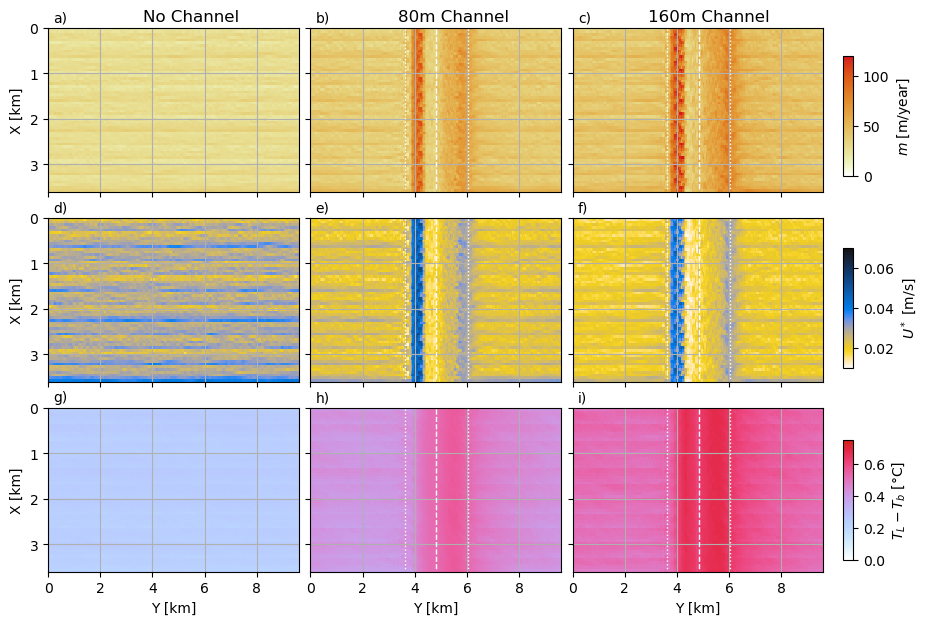

In [28]:
fig = plt.figure(figsize=(10,12))

gs = GridSpec(15, 6, figure=fig)
######## Time series ##########
# ax1 = fig.add_subplot(gs[0:5, 0:5])
# ax1_ = fig.add_subplot(gs[0:5, 5])
ax2 = fig.add_subplot(gs[6:9,  0:2])
ax3 = fig.add_subplot(gs[9:12, 0:2])
ax4 = fig.add_subplot(gs[12:15, 0:2])
ax5 = fig.add_subplot(gs[6:9, 2:4])
ax6 = fig.add_subplot(gs[9:12, 2:4])
ax7 = fig.add_subplot(gs[12:15, 2:4])
ax8 = fig.add_subplot(gs[6:9, 4:])
ax9 = fig.add_subplot(gs[9:12, 4:])
ax10 = fig.add_subplot(gs[12:15, 4:])

ax= [ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
counter = 0 

mmin=0
mmax=120

umin=0.01
umax=0.07

tmin= 0.0
tmax= 0.75

for var in var_names:
    if "ryan" in var:
        continue
    
    if "dz8" in var:
        color="tan"
        marker="."
    elif "dz4" in var:
        color="peru"
        marker="*"
    elif "dz2" in var:
        color="orange"
        marker="d"
        
    if "c80m" in var:
        linestyle="-"
    elif "c160m" in var:
        linestyle="--"
    elif "c0m" in var:
        linestyle="-."


    cond = ("vshift48_dz2" in var)

    if "Td2" in var and cond:
        print(var)
##### Melt rate  #####
        channel = int(var.split("_c")[1].split("m_")[0]) 
        Melt = M[var].dropna("time").isel(time=-1)
        cbar1 = Melt.plot(x="YC",ax=ax[counter],vmin=mmin,vmax=mmax,cmap=ccm.cm.CET_L18,add_colorbar=False,rasterized=True)
        if "c0m" not in var:
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[80].values,Melt.XC,linestyle='--',color='w',linewidth=1)
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[100].values,Melt.XC,linestyle=':',color='w',linewidth=1)
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[60].values,Melt.XC,linestyle=':',color='w',linewidth=1)
        counter+=1
##### U star  #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        channel = int(var.split("_c")[1].split("m_")[0]) 
        Ustar_plot = Ustar[ustar_var].dropna("time").isel(time=-1)
        cbar2 = Ustar_plot.plot(x="YC",ax=ax[counter],vmin=umin,vmax=umax,cmap=ccm.cm.CET_CBL2_r,add_colorbar=False,rasterized=True)
        if "c0m" not in var:
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[80].values,Melt.XC,linestyle='--',color='w',linewidth=1)
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[100].values,Melt.XC,linestyle=':',color='w',linewidth=1)
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[60].values,Melt.XC,linestyle=':',color='w',linewidth=1)
        counter+=1
##### TD  #####
        channel = int(var.split("_c")[1].split("m_")[0]) 
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].dropna("time").isel(time=-1)
        cbar3 = Tf.plot(x="YC",ax=ax[counter], vmin=tmin, vmax=tmax,cmap=ccm.cm.CET_L19,add_colorbar=False,rasterized=True)
        if "c0m" not in var:
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[80].values,Melt.XC,linestyle='--',color='w',linewidth=1)
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[100].values,Melt.XC,linestyle=':',color='w',linewidth=1)
            ax[counter].plot(np.ones_like(Melt.XC)*Melt.YC[60].values,Melt.XC,linestyle=':',color='w',linewidth=1)
        counter+=1

        # break
    # plt.errorbar(x, y, e, linestyle='None', marker='^')
# ax5.plot([100,110],[100,110],linestyle='--',color='gray')

[a.grid() for a in [ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10]]
[a.set_xlabel("") for a in [ax2,ax3,ax5,ax6,ax8,ax9]]
[a.set_xlabel("Y [km]") for a in [ax4,ax7,ax10]]
[a.set_title("") for a in [ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10]]
[a.set_ylabel("") for a in [ax5,ax6,ax7,ax8,ax9,ax10]]
[a.set_ylabel("X [km]") for a in [ax2,ax3,ax4]]
[a.yaxis.set_ticklabels([]) for a in [ax5,ax6,ax7,ax8,ax9,ax10]]
[a.xaxis.set_ticklabels([]) for a in [ ax2,ax3, ax5,ax6,ax8,ax9]]

# ax2.set_ylabel("Meltrate [m/year]")
# ax3.set_ylabel(r"$U^*$"+" [m/s]")
# ax4.set_ylabel(r"$T_f$"+" [°C]")


cbar_ax = fig.add_axes([0.92, 0.44, 0.01, 0.1])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$m$ [m/year]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.92, 0.28, 0.01, 0.1])
fig.colorbar(cbar2, cax =cbar_ax)
cbar_ax.set_ylabel(r"$U^*$"+" [m/s]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.1])
fig.colorbar(cbar3, cax =cbar_ax)
cbar_ax.set_ylabel(r"$T_L-T_b$"+" [°C]")
cbar_ax.yaxis.set_tick_params(labelsize=10)


ax2.text(0.38, 1.04, "No Channel", fontsize=12, transform=ax2.transAxes)
ax5.text(0.35, 1.04, "80m Channel", fontsize=12, transform=ax5.transAxes)
ax8.text(0.3, 1.04, "160m Channel", fontsize=12, transform=ax8.transAxes)
# ax3.text(0.45, 1.04, "dz=2m", fontsize=10, transform=ax3.transAxes)
# ax6.text(0.45, 1.04, "dz=4m", fontsize=10, transform=ax6.transAxes)
# ax9.text(0.45, 1.04, "dz=8m", fontsize=10, transform=ax9.transAxes)
# ax4.text(0.45, 1.04, "dz=2m", fontsize=10, transform=ax4.transAxes)
# ax7.text(0.45, 1.04, "dz=4m", fontsize=10, transform=ax7.transAxes)
# ax10.text(0.45, 1.04, "dz=8m", fontsize=10, transform=ax10.transAxes)

ax2.text(0.02, 1.04, "a)", fontsize=10, transform=ax2.transAxes)
ax5.text(0.02, 1.04, "b)", fontsize=10, transform=ax5.transAxes)
ax8.text(0.02, 1.04, "c)", fontsize=10, transform=ax8.transAxes)
ax3.text(0.02, 1.04, "d)", fontsize=10, transform=ax3.transAxes)
ax6.text(0.02, 1.04, "e)", fontsize=10, transform=ax6.transAxes)
ax9.text(0.02, 1.04, "f)", fontsize=10, transform=ax9.transAxes)
ax4.text(0.02, 1.04, "g)", fontsize=10, transform=ax4.transAxes)
ax7.text(0.02, 1.04, "h)", fontsize=10, transform=ax7.transAxes)
ax10.text(0.02, 1.04, "i)", fontsize=10, transform=ax10.transAxes)

ax=[ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10]
[a.invert_yaxis() for a in ax]

plt.subplots_adjust(wspace=0.1, hspace=0.7)
plt.savefig('./figures/Fig_5_meltrate_us_channels.pdf'.format(c), dpi=300, bbox_inches='tight')

In [29]:
print(Melt.YC[100])
print(Melt.YC[80])
print(Melt.YC[60])

<xarray.DataArray 'YC' ()> Size: 4B
array(6.03, dtype=float32)
Coordinates:
    YC       float32 4B 6.03
    time     float64 8B 1.08e+03
    iter     int64 8B dask.array<chunksize=(), meta=np.ndarray>
<xarray.DataArray 'YC' ()> Size: 4B
array(4.83, dtype=float32)
Coordinates:
    YC       float32 4B 4.83
    time     float64 8B 1.08e+03
    iter     int64 8B dask.array<chunksize=(), meta=np.ndarray>
<xarray.DataArray 'YC' ()> Size: 4B
array(3.63, dtype=float32)
Coordinates:
    YC       float32 4B 3.63
    time     float64 8B 1.08e+03
    iter     int64 8B dask.array<chunksize=(), meta=np.ndarray>


## Supplementary figure to compare viscosities

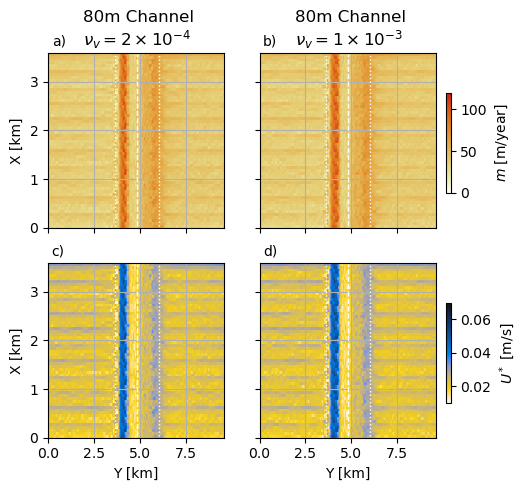

In [30]:
fig,ax = plt.subplots(2,2,figsize=(5,5))

axs=ax.ravel()

mmin=0
mmax=120

cbar1=M.SHIfwFlx_c80m_Td2_vshift48_dz2.dropna("time").isel(time=-1).plot(x="YC",ax=axs[0],vmin=mmin,vmax=mmax,cmap=ccm.cm.CET_L18,add_colorbar=False,rasterized=True)
M.SHIfwFlx_c80m_Td2_vshift48_visc_dz2.dropna("time").isel(time=-1).plot(x="YC",ax=axs[1],vmin=mmin,vmax=mmax,cmap=ccm.cm.CET_L18,add_colorbar=False,rasterized=True)

umin=0.01
umax=0.07

cbar2= Ustar.SHIuStar_c80m_Td2_vshift48_dz2.dropna("time").isel(time=-1).plot(x="YC",ax=axs[2],vmin=umin,vmax=umax,cmap=ccm.cm.CET_CBL2_r,add_colorbar=False,rasterized=True)
Ustar.SHIuStar_c80m_Td2_vshift48_visc_dz2.dropna("time").isel(time=-1).plot(x="YC",ax=axs[3],vmin=umin,vmax=umax,cmap=ccm.cm.CET_CBL2_r,add_colorbar=False,rasterized=True)

cbar_ax = fig.add_axes([0.92, 0.6, 0.01, 0.2])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$m$ [m/year]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.92, 0.18, 0.01, 0.2])
fig.colorbar(cbar2, cax =cbar_ax)
cbar_ax.set_ylabel(r"$U^*$"+" [m/s]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

[a.grid() for a in axs]
[a.set_xlabel("") for a in axs]
[a.set_xlabel("Y [km]") for a in ax[1,:]]
[a.set_title("") for a in axs]
[a.set_ylabel("") for a in axs]
[a.set_ylabel("X [km]") for a in ax[:,0]]
[a.yaxis.set_ticklabels([]) for a in ax[:,1]]
[a.xaxis.set_ticklabels([]) for a in ax[0,:]]

for a in axs:
    Melt= M.SHIfwFlx_c80m_Td2_vshift48_dz2
    a.plot(np.ones_like(Melt.XC)*Melt.YC[80].values,Melt.XC,linestyle='--',color='w',linewidth=1)
    a.plot(np.ones_like(Melt.XC)*Melt.YC[100].values,Melt.XC,linestyle=':',color='w',linewidth=1)
    a.plot(np.ones_like(Melt.XC)*Melt.YC[60].values,Melt.XC,linestyle=':',color='w',linewidth=1)

axs[0].text(0.2, 1.04, "80m Channel\n"+r"$\nu_v= 2\times10^{-4}$", fontsize=12, transform=axs[0].transAxes)
axs[1].text(0.2, 1.04, "80m Channel\n"+r"$\nu_v= 1\times10^{-3}$", fontsize=12, transform=axs[1].transAxes)

axs[0].text(0.02, 1.04, "a)", fontsize=10, transform=axs[0].transAxes)
axs[1].text(0.02, 1.04, "b)", fontsize=10, transform=axs[1].transAxes)
axs[2].text(0.02, 1.04, "c)", fontsize=10, transform=axs[2].transAxes)
axs[3].text(0.02, 1.04, "d)", fontsize=10, transform=axs[3].transAxes)

plt.savefig('./figures/SFig_3_meltrate_us_visc.pdf'.format(c), dpi=300, bbox_inches='tight')